# F02 · From tissue to MRI contrast to BOLD

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PB01](../../curriculum/papers/measurement.md#pb01).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** What evidence would justify moving from a BOLD change to a claim about neural activity?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Learning format:** predict → ask AI for one short operation → run → inspect → deliberately break → explain. Use Goose with a local Ollama model, or ChatGPT as a tutor and snippet writer. You are responsible for deciding whether the transformation answers the research question. Read the answer guide only after making your own prediction.

**Time:** 90 minutes. **Prerequisite:** F01. This is a bridge into the four strands, not a substitute for neuroanatomy or MRI physics.

MRI contrast depends on acquisition as well as tissue. T1 describes longitudinal recovery; T2 describes transverse decay associated with irreversible dephasing in a spin-echo picture. T2* also includes reversible dephasing from field inhomogeneity and is no larger than T2 in the simple rate model. TR and TE are sequence timing choices, not tissue constants. T2 and T2* are different quantities; the duplicated “T2” in the original proposed outline should not erase this distinction.

An idealized spin-echo signal has a recovery factor and a decay factor: S is proportional to proton density times (1−exp(−TR/T1)) times exp(−TE/T2). This toy expression omits many sequence details and is not a quantitative tissue-fitting protocol. It is enough to explain why increasing TR reduces one source of T1 weighting, and why longer TE attenuates short-T2 tissue more strongly. “Brighter” alone does not identify pathology or tissue type.

BOLD is an indirect hemodynamic contrast with sensitivity to oxygenation and vascular effects, often acquired using T2*-sensitive gradient-echo EPI. The time course is delayed and blurred relative to neural events. Convolving event timing with an assumed hemodynamic response makes a model prediction; it does not observe neural firing. Task effects can be mixed with motion, physiology, drift, and scanner artifacts. Each later preprocessing or statistical decision must be interpreted against this measurement chain.

Anatomical structures, tissue compartments, cortical versus subcortical systems, and the relation of an ROI to the biological question still need supervised study. Use the [DartBrains MRI introduction](https://dartbrains.org/MR_Physics/) and the [Oxford FSL course](https://fsl.fmrib.ox.ac.uk/fslcourse/) introductory material as the longer source assignment. Explain at least one acquisition limitation before proceeding to a statistical map.


### Contrast can reverse
Predict whether the ordering of these two illustrative tissues is fixed across sequence settings.

In [1]:
import numpy as np
T1 = np.array([0.8, 1.4]) # seconds; illustrative only
T2 = np.array([0.08, 0.12])
def spin_echo(tr, te):
    return (1-np.exp(-tr/T1))*np.exp(-te/T2)
short = spin_echo(0.5,0.015)
long = spin_echo(4.0,0.10)
print('short TR/TE:',short,'long TR/TE:',long)
assert short[0] > short[1]
assert long[0] < long[1]

short TR/TE: [0.38528181 0.26503806] long TR/TE: [0.28457434 0.4096381 ]


### T2* decay and delayed observations
Changing the effective decay time changes gradient-echo signal. Predict which curve decays faster.

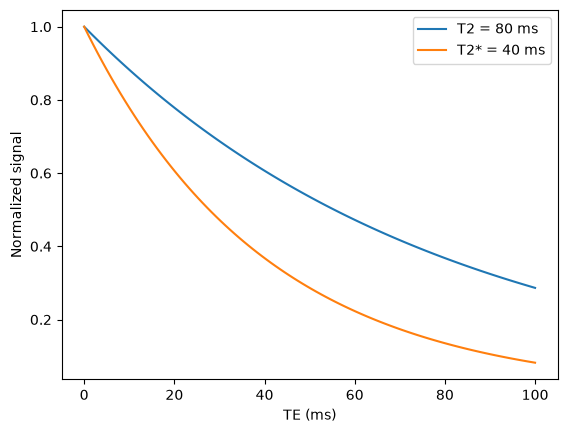

In [2]:
import matplotlib.pyplot as plt
te = np.linspace(0,0.1,100)
t2, t2star = 0.08, 0.04
plt.plot(te*1000,np.exp(-te/t2),label='T2 = 80 ms')
plt.plot(te*1000,np.exp(-te/t2star),label='T2* = 40 ms')
plt.xlabel('TE (ms)'); plt.ylabel('Normalized signal'); plt.legend(); plt.show()
assert np.all(np.exp(-te/t2star) <= np.exp(-te/t2))

## Explain without AI

1. Explain why tissue contrast reverses in the toy example without changing either tissue.
2. State why an MRI intensity is not automatically a quantitative tissue parameter.
3. Predict what goes wrong when TE in milliseconds is used with T2 in seconds.
4. Explain why a BOLD association cannot by itself establish a specific neural mechanism.

<details><summary>Answer guide</summary>TR and TE weight recovery and decay differently. Mixing milliseconds with seconds creates a thousandfold exponent error. The formulas are simplified measurement models. BOLD depends on vascular and neural contributions; later regression does not remove the need for a biological interpretation.</details>

**Submission:** record the input, operation, parameters, output, one preserved property, one lost property, and the evidence that would make you reject the result. Include the prompt and any corrections you made to the generated code. A saved answer is not evidence of understanding until you can defend it orally.


### Return to the research question

Reopen [PB01](../../curriculum/papers/measurement.md#pb01) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
